 Instalação e Importações

In [1]:
# Instalação e Importação de Bibliotecas
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

print(f"TensorFlow versão: {tf.__version__}")

TensorFlow versão: 2.20.0


Carregar e Preparar o Dataset MNIST

In [2]:
# Carregamento do Dataset MNIST
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalização dos pixels para o intervalo [0, 1]
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

print(f"Treino: {x_train.shape} | Teste: {x_test.shape}")
print(f"Classes: {np.unique(y_train)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino: (60000, 28, 28, 1) | Teste: (10000, 28, 28, 1)
Classes: [0 1 2 3 4 5 6 7 8 9]


Definição e Treinamento do Modelo CNN

In [3]:
# Definição do Modelo CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Treinamento
print("\nTreinando o modelo...")
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)


Treinando o modelo...
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 53s 58ms/step - accuracy: 0.9384 - loss: 0.2027 - val_accuracy: 0.9808 - val_loss: 0.0636
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - accuracy: 0.9819 - loss: 0.0562 - val_accuracy: 0.9867 - val_loss: 0.0458
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9880 - loss: 0.0392 - val_accuracy: 0.9880 - val_loss: 0.0428
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9907 - val_loss: 0.0349
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9924 - loss: 0.0240 - val_accuracy: 0.9902 - val_loss: 0.0377


Geração das Predições

In [4]:
# Geração das predições no conjunto de teste
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

print(f"Total de amostras de teste: {len(y_true)}")
print(f"Exemplo y_true: {y_true[:10]}")
print(f"Exemplo y_pred: {y_pred[:10]}")

Total de amostras de teste: 10000
Exemplo y_true: [7 2 1 0 4 1 4 9 5 9]
Exemplo y_pred: [7 2 1 0 4 1 4 9 5 9]


Geração e Visualização da Matriz de Confusão

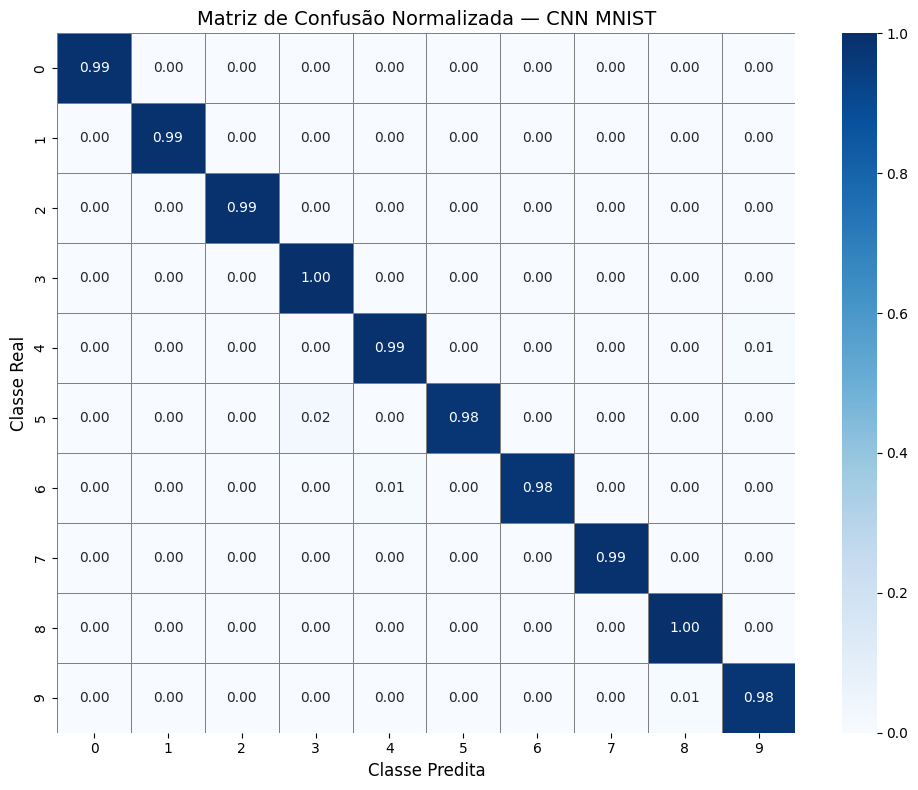


Matriz de Confusão (valores absolutos):
[[ 975    0    0    0    0    0    1    1    0    3]
 [   0 1129    0    1    0    0    0    0    5    0]
 [   0    2 1020    1    2    0    1    4    2    0]
 [   0    0    1 1006    0    2    0    0    0    1]
 [   0    0    0    0  977    0    0    0    0    5]
 [   2    0    0   14    0  871    1    0    0    4]
 [   2    2    0    1    5    4  942    0    2    0]
 [   0    2    2    3    0    0    0 1013    4    4]
 [   1    0    1    0    0    0    0    0  971    1]
 [   0    0    0    0    5    2    0    2    7  993]]


In [5]:
# Matriz de Confusão
classes = list(range(10))

con_mat = confusion_matrix(y_true, y_pred)
con_mat_norm = np.around(
    con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis],
    decimals=2
)

con_mat_df = pd.DataFrame(con_mat_norm, index=classes, columns=classes)

plt.figure(figsize=(10, 8))
sns.heatmap(con_mat_df, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.title('Matriz de Confusão Normalizada — CNN MNIST', fontsize=14)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nMatriz de Confusão (valores absolutos):")
print(con_mat)

Cálculo Manual das Métricas (objetivo principal)

In [6]:
def calcular_metricas(y_true, y_pred, classes):
    """
    Calcula VP, VN, FP, FN e todas as métricas para cada classe.
    Abordagem: One-vs-Rest (cada classe vs todas as outras)
    """
    resultados = []

    for classe in classes:
        # Binarizar: classe atual = positivo, demais = negativo
        y_true_bin = (y_true == classe).astype(int)
        y_pred_bin = (y_pred == classe).astype(int)

        VP = np.sum((y_true_bin == 1) & (y_pred_bin == 1))  # Verdadeiro Positivo
        VN = np.sum((y_true_bin == 0) & (y_pred_bin == 0))  # Verdadeiro Negativo
        FP = np.sum((y_true_bin == 0) & (y_pred_bin == 1))  # Falso Positivo
        FN = np.sum((y_true_bin == 1) & (y_pred_bin == 0))  # Falso Negativo
        N  = len(y_true)                                     # Total de elementos

        # Cálculo das métricas conforme Tabela 1
        sensibilidade = VP / (VP + FN) if (VP + FN) > 0 else 0.0   # Recall
        especificidade = VN / (FP + VN) if (FP + VN) > 0 else 0.0
        acuracia       = (VP + VN) / N  if N > 0 else 0.0
        precisao       = VP / (VP + FP) if (VP + FP) > 0 else 0.0
        f_score        = (2 * precisao * sensibilidade) / (precisao + sensibilidade) \
                         if (precisao + sensibilidade) > 0 else 0.0

        resultados.append({
            'Classe': classe,
            'VP': VP, 'VN': VN, 'FP': FP, 'FN': FN,
            'Sensibilidade (Recall)': round(sensibilidade, 4),
            'Especificidade':         round(especificidade, 4),
            'Acurácia':               round(acuracia, 4),
            'Precisão':               round(precisao, 4),
            'F-Score':                round(f_score, 4)
        })

    return pd.DataFrame(resultados)

# Executar cálculo
classes = list(range(10))
df_metricas = calcular_metricas(y_true, y_pred, classes)

print("=" * 70)
print("  MÉTRICAS DE AVALIAÇÃO POR CLASSE — Tabela 1")
print("=" * 70)
print(df_metricas.to_string(index=False))

  MÉTRICAS DE AVALIAÇÃO POR CLASSE — Tabela 1
 Classe   VP   VN  FP  FN  Sensibilidade (Recall)  Especificidade  Acurácia  Precisão  F-Score
      0  975 9015   5   5                  0.9949          0.9994    0.9990    0.9949   0.9949
      1 1129 8859   6   6                  0.9947          0.9993    0.9988    0.9947   0.9947
      2 1020 8964   4  12                  0.9884          0.9996    0.9984    0.9961   0.9922
      3 1006 8970  20   4                  0.9960          0.9978    0.9976    0.9805   0.9882
      4  977 9006  12   5                  0.9949          0.9987    0.9983    0.9879   0.9914
      5  871 9100   8  21                  0.9765          0.9991    0.9971    0.9909   0.9836
      6  942 9039   3  16                  0.9833          0.9997    0.9981    0.9968   0.9900
      7 1013 8965   7  15                  0.9854          0.9992    0.9978    0.9931   0.9893
      8  971 9006  20   3                  0.9969          0.9978    0.9977    0.9798   0.9883
    

Métricas Globais do Modelo

In [7]:
# Métricas Globais (média macro)
print("\n" + "=" * 50)
print("  MÉTRICAS GLOBAIS (Média Macro)")
print("=" * 50)
print(f"  Sensibilidade média: {df_metricas['Sensibilidade (Recall)'].mean():.4f}")
print(f"  Especificidade média:{df_metricas['Especificidade'].mean():.4f}")
print(f"  Acurácia média:      {df_metricas['Acurácia'].mean():.4f}")
print(f"  Precisão média:      {df_metricas['Precisão'].mean():.4f}")
print(f"  F-Score médio:       {df_metricas['F-Score'].mean():.4f}")
print("=" * 50)

# Acurácia geral do modelo
acuracia_geral = np.sum(y_true == y_pred) / len(y_true)
print(f"\n  Acurácia geral do modelo: {acuracia_geral:.4f} ({acuracia_geral*100:.2f}%)")


  MÉTRICAS GLOBAIS (Média Macro)
  Sensibilidade média: 0.9895
  Especificidade média:0.9989
  Acurácia média:      0.9979
  Precisão média:      0.9897
  F-Score médio:       0.9896

  Acurácia geral do modelo: 0.9897 (98.97%)


Visualização das Métricas

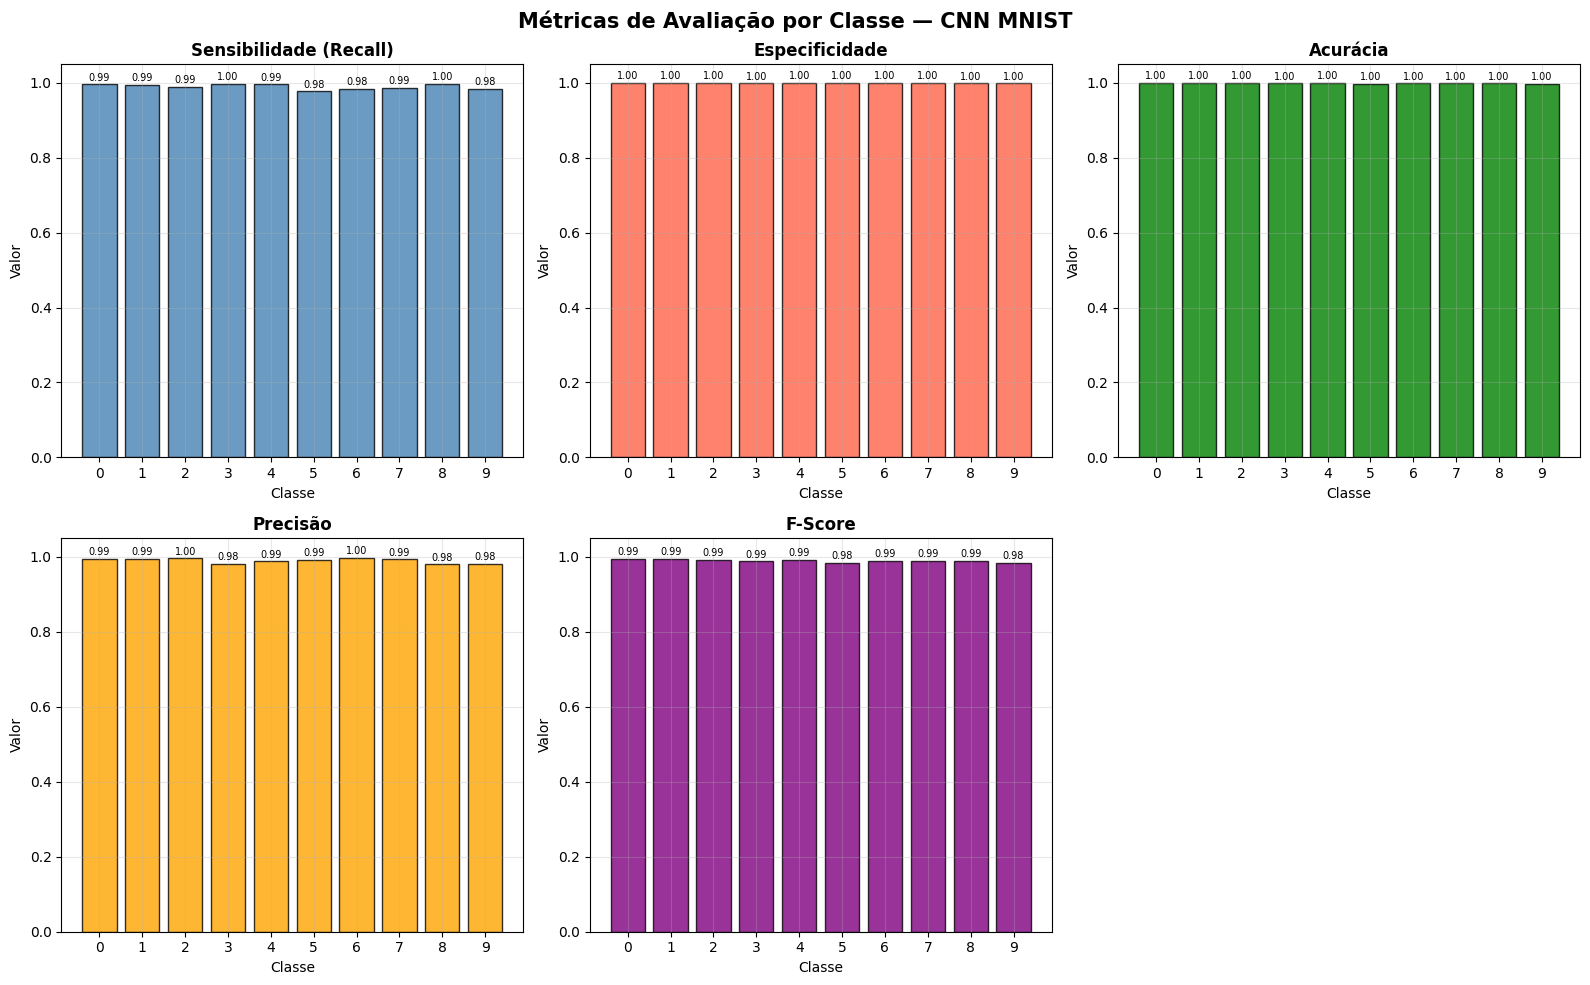

In [8]:
# Visualização comparativa das métricas por classe
metricas_plot = ['Sensibilidade (Recall)', 'Especificidade',
                 'Acurácia', 'Precisão', 'F-Score']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['steelblue', 'tomato', 'green', 'orange', 'purple']

for i, metrica in enumerate(metricas_plot):
    axes[i].bar(df_metricas['Classe'], df_metricas[metrica],
                color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(metrica, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Classe')
    axes[i].set_ylabel('Valor')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_xticks(range(10))
    axes[i].grid(True, alpha=0.3)
    for j, val in enumerate(df_metricas[metrica]):
        axes[i].text(j, val + 0.01, f'{val:.2f}', ha='center', fontsize=7)

# Esconder o 6º subplot (não usado)
axes[5].axis('off')

plt.suptitle('Métricas de Avaliação por Classe — CNN MNIST',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('metricas_por_classe.png', dpi=150)
plt.show()

Curvas de Aprendizado

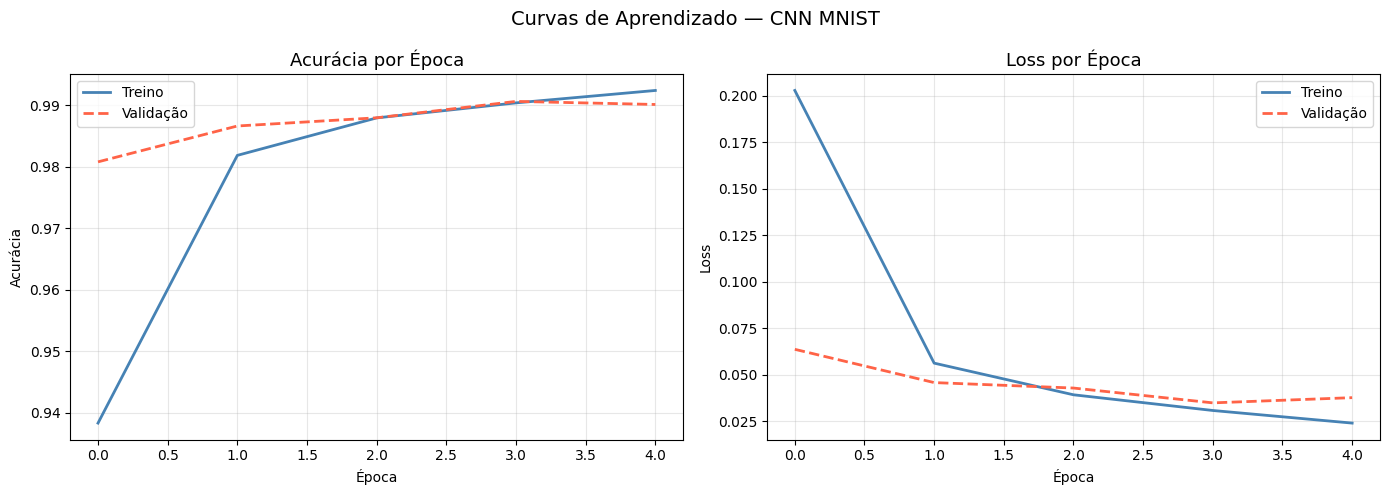

In [9]:
# Curvas de Aprendizado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Treino',    color='steelblue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validação', color='tomato',    linewidth=2, linestyle='--')
ax1.set_title('Acurácia por Época', fontsize=13)
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Treino',    color='steelblue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validação', color='tomato',    linewidth=2, linestyle='--')
ax2.set_title('Loss por Época', fontsize=13)
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizado — CNN MNIST', fontsize=14)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

Salvar Resultados

In [10]:
# Salvar tabela de métricas em CSV
df_metricas.to_csv('metricas_avaliacao.csv', index=False)
print("Arquivo 'metricas_avaliacao.csv' salvo com sucesso!")
print("\nResumo final:")
print(df_metricas[['Classe','Acurácia','Precisão',
                    'Sensibilidade (Recall)','F-Score']].to_string(index=False))

Arquivo 'metricas_avaliacao.csv' salvo com sucesso!

Resumo final:
 Classe  Acurácia  Precisão  Sensibilidade (Recall)  F-Score
      0    0.9990    0.9949                  0.9949   0.9949
      1    0.9988    0.9947                  0.9947   0.9947
      2    0.9984    0.9961                  0.9884   0.9922
      3    0.9976    0.9805                  0.9960   0.9882
      4    0.9983    0.9879                  0.9949   0.9914
      5    0.9971    0.9909                  0.9765   0.9836
      6    0.9981    0.9968                  0.9833   0.9900
      7    0.9978    0.9931                  0.9854   0.9893
      8    0.9977    0.9798                  0.9969   0.9883
      9    0.9966    0.9822                  0.9841   0.9832
